# DNN Architecture R&D

Explore DNN architectures for raw-input bet prediction (11 raw market columns, no pre-computed indicators).

**Goal:** Compare at least 3 architectures on accuracy, Brier score, F1, training time, and inference latency. Select the winner for production use.

**Raw input columns (11):** `btc_price`, `elapsed_pct`, `market_volume`, `up_best_bid`, `up_best_ask`, `up_bid_depth`, `up_ask_depth`, `down_best_bid`, `down_best_ask`, `down_bid_depth`, `down_ask_depth`

**Architectures to compare:**
1. Residual MLP (baseline) — single snapshot
2. Temporal Conv1D — causal convolutions over snapshot sequences
3. Attention-based — self-attention over snapshot sequences

## 1. Data Loading & Preparation

In [1]:
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PyTorch 2.11.0
CUDA available: False


In [2]:
RAW_COLS = [
    "btc_price",
    "elapsed_pct",
    "market_volume",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
]

# Load features and build per-candle aggregated dataset
rows = []
with open("../../data/latest_features.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f"Total snapshots: {len(df):,}")
print(f"Candles: {df['candle_id'].nunique():,}")
print(f"Columns: {len(df.columns)}")

# Target: outcome column (1=UP, 0=DOWN)
df["target"] = (df["outcome"] == "UP").astype(int)
print(f"Class balance: UP={df['target'].mean():.3f} DOWN={1 - df['target'].mean():.3f}")

Total snapshots: 245,319
Candles: 5,187
Columns: 75
Class balance: UP=0.512 DOWN=0.488


### Filter to mid-candle snapshots only (no data leakage)

In production, `ModelRunner` calls `predict(row)` on ticks as they arrive — typically at 5-70% elapsed (entry points range from 0.05 to 0.70). Using end-of-candle data would leak the outcome. We filter to `elapsed_pct <= 0.50` to match realistic inference conditions.

For the **MLP baseline**, we take the last snapshot before the cutoff (most information available at prediction time). For **temporal models**, sequences include only snapshots up to the cutoff.

In [3]:
ELAPSED_CUTOFF = 0.50

# Filter to mid-candle snapshots only
df_mid = df[df["elapsed_pct"] <= ELAPSED_CUTOFF].copy()
print(f"Snapshots after cutoff filter: {len(df_mid):,} / {len(df):,} ({len(df_mid) / len(df) * 100:.0f}%)")

# Per-candle: take last snapshot before cutoff
candle_df = df_mid.groupby("candle_id").last().reset_index()
print(f"Candles for single-snapshot: {len(candle_df):,}")

X_all = candle_df[RAW_COLS].fillna(0).values.astype(np.float32)
y_all = candle_df["target"].values.astype(np.float32)

# 80/20 time-ordered split (no shuffle — respects temporal order)
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {len(X_train):,} candles | Test: {len(X_test):,} candles")

Snapshots after cutoff filter: 122,289 / 245,319 (50%)
Candles for single-snapshot: 5,187
Train: 4,149 candles | Test: 1,038 candles


### Build sequence dataset for temporal models

Group snapshots by candle, pad/truncate to fixed length (50 snapshots per candle).

In [4]:
SEQ_LEN = 50

# Build sequences from mid-candle snapshots only (elapsed_pct <= cutoff)
candle_ids_ordered = df_mid["candle_id"].unique()
sequences = []
seq_targets = []

for cid in candle_ids_ordered:
    group = df_mid[df_mid["candle_id"] == cid]
    feats = group[RAW_COLS].fillna(0).values.astype(np.float32)
    target = int(group["target"].iloc[0])

    # Pad (repeat first row) or truncate
    if len(feats) < SEQ_LEN:
        pad = np.tile(feats[0:1], (SEQ_LEN - len(feats), 1))
        feats = np.vstack([pad, feats])
    else:
        feats = feats[-SEQ_LEN:]

    sequences.append(feats)
    seq_targets.append(target)

X_seq = np.array(sequences, dtype=np.float32)  # (n_candles, SEQ_LEN, 11)
y_seq = np.array(seq_targets, dtype=np.float32)

# Scale along feature axis (fit on train portion)
X_seq_flat = X_seq.reshape(-1, len(RAW_COLS))
seq_scaler = StandardScaler()
seq_scaler.fit(X_seq_flat[: split_idx * SEQ_LEN])
X_seq_scaled = seq_scaler.transform(X_seq_flat).reshape(X_seq.shape)

X_seq_train = X_seq_scaled[:split_idx]
X_seq_test = X_seq_scaled[split_idx:]
y_seq_train = y_seq[:split_idx]
y_seq_test = y_seq[split_idx:]

print(f"Sequence shape: {X_seq.shape}")
print(f"Train sequences: {len(X_seq_train):,} | Test: {len(X_seq_test):,}")

Sequence shape: (5187, 50, 11)
Train sequences: 4,149 | Test: 1,038


## 2. Training Harness

Shared training loop used by all architectures.

In [5]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, patience=8, lr=0.001, batch_size=256):
    """Train a PyTorch model with early stopping. Returns best val loss."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    loss_fn = nn.BCEWithLogitsLoss()

    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_v = torch.tensor(X_val, dtype=torch.float32)
    y_v = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_v)
            vl = loss_fn(val_logits, y_v).item()
            val_probs = torch.sigmoid(val_logits)
            va = ((val_probs >= 0.5).float() == y_v).float().mean().item()

        history.append({"epoch": epoch, "val_loss": vl, "val_acc": va})

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        scheduler.step()

        if no_improve >= patience:
            print(f"  Early stop at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

    if best_state:
        model.load_state_dict(best_state)

    return best_val_loss, history


def evaluate_model(model, X_test, y_test):
    """Evaluate a trained model. Returns dict of metrics + probabilities."""
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32)

    # Inference latency (per sample)
    n_warmup = 10
    for _ in range(n_warmup):
        with torch.no_grad():
            model(X_t[:1])

    t0 = time.perf_counter()
    n_iters = 100
    for _ in range(n_iters):
        with torch.no_grad():
            model(X_t[:1])
    latency_ms = (time.perf_counter() - t0) / n_iters * 1000

    # Full predictions
    with torch.no_grad():
        logits = model(X_t)
        probs = torch.sigmoid(logits).numpy().flatten()

    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_test, preds),
        "brier": brier_score_loss(y_test, probs),
        "f1": f1_score(y_test, preds, zero_division=0),
        "latency_ms": latency_ms,
        "probs": probs,
        "preds": preds,
    }


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_metrics(name, metrics, params, train_time):
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  Parameters:  {params:,}")
    print(f"  Train time:  {train_time:.1f}s")
    print(f"  Latency:     {metrics['latency_ms']:.2f} ms/sample")
    print(f"  Accuracy:    {metrics['accuracy'] * 100:.1f}%")
    print(f"  Brier:       {metrics['brier']:.4f}")
    print(f"  F1:          {metrics['f1'] * 100:.1f}%")

## 3. Architecture A: Residual MLP (baseline)

Single-snapshot model. Input(11) -> residual blocks with skip connections, LayerNorm, Dropout -> logit output.

This is similar to the existing `_dnn_worker.py` architecture but purpose-built for 11 raw features. Uses `BCEWithLogitsLoss` (no sigmoid in model output) for numerical stability.

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden_size, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class ResidualMLP(nn.Module):
    """Residual MLP for single-snapshot prediction."""

    def __init__(self, input_size=11, hidden=128, n_blocks=4, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)  # raw logit — sigmoid applied externally


print("ResidualMLP defined")

ResidualMLP defined


In [7]:
# Train Residual MLP
mlp = ResidualMLP()
print(f"Residual MLP: {count_params(mlp):,} parameters")

t0 = time.perf_counter()
mlp_val_loss, mlp_history = train_model(mlp, X_train_s, y_train, X_test_s, y_test)
mlp_train_time = time.perf_counter() - t0

mlp_metrics = evaluate_model(mlp, X_test_s, y_test)
print_metrics("Residual MLP", mlp_metrics, count_params(mlp), mlp_train_time)

Residual MLP: 136,065 parameters


  Early stop at epoch 21 (best val_loss=0.5493)

  Residual MLP
  Parameters:  136,065
  Train time:  1.5s
  Latency:     0.08 ms/sample
  Accuracy:    72.6%
  Brier:       0.1843
  F1:          73.4%


## 4. Architecture B: Temporal Conv1D

Causal 1D convolutions over snapshot sequences within a candle. Each conv layer sees only past and current timesteps (no future leakage). Global average pooling then classification head.

In [8]:
class CausalConv1d(nn.Module):
    """1D convolution with causal padding (no future leakage)."""

    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation)

    def forward(self, x):
        out = self.conv(x)
        if self.padding > 0:
            out = out[:, :, : -self.padding]
        return out


class TemporalConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(channels, channels, kernel_size, dilation),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
            CausalConv1d(channels, channels, kernel_size, dilation),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))


class TemporalConv1D(nn.Module):
    """Causal temporal convolution for sequence classification."""

    def __init__(self, input_size=11, hidden=64, n_blocks=3, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, hidden, 1)  # pointwise projection
        self.blocks = nn.ModuleList(
            [TemporalConvBlock(hidden, kernel_size=3, dilation=2**i, dropout=dropout) for i in range(n_blocks)]
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (batch, seq_len, features) -> (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        # Global average pooling over time
        x = x.mean(dim=2)  # (batch, hidden)
        return self.head(x)


print("TemporalConv1D defined")

TemporalConv1D defined


In [9]:
# Train Temporal Conv1D
tcn = TemporalConv1D()
print(f"Temporal Conv1D: {count_params(tcn):,} parameters")

t0 = time.perf_counter()
tcn_val_loss, tcn_history = train_model(tcn, X_seq_train, y_seq_train, X_seq_test, y_seq_test)
tcn_train_time = time.perf_counter() - t0

tcn_metrics = evaluate_model(tcn, X_seq_test, y_seq_test)
print_metrics("Temporal Conv1D", tcn_metrics, count_params(tcn), tcn_train_time)

Temporal Conv1D: 75,713 parameters


  Early stop at epoch 15 (best val_loss=0.5510)



  Temporal Conv1D
  Parameters:  75,713
  Train time:  38.0s
  Latency:     0.37 ms/sample
  Accuracy:    72.3%
  Brier:       0.1857
  F1:          72.4%


## 5. Architecture C: Self-Attention

Lightweight self-attention over snapshot sequences. Positional encoding via learned embeddings. Multi-head attention with 2 layers, then mean-pool and classify.

In [10]:
class SnapshotAttention(nn.Module):
    """Lightweight self-attention for snapshot sequences."""

    def __init__(self, input_size=11, d_model=64, n_heads=4, n_layers=2, seq_len=50, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x) + self.pos_embed
        x = self.encoder(x)
        x = x.mean(dim=1)  # mean pool over sequence
        return self.head(x)


print("SnapshotAttention defined")

SnapshotAttention defined


In [11]:
# Train Snapshot Attention
attn = SnapshotAttention()
print(f"Snapshot Attention: {count_params(attn):,} parameters")

t0 = time.perf_counter()
attn_val_loss, attn_history = train_model(attn, X_seq_train, y_seq_train, X_seq_test, y_seq_test)
attn_train_time = time.perf_counter() - t0

attn_metrics = evaluate_model(attn, X_seq_test, y_seq_test)
print_metrics("Snapshot Attention", attn_metrics, count_params(attn), attn_train_time)

Snapshot Attention: 70,977 parameters


  Early stop at epoch 12 (best val_loss=0.5532)

  Snapshot Attention
  Parameters:  70,977
  Train time:  12.8s
  Latency:     0.24 ms/sample
  Accuracy:    73.2%
  Brier:       0.1859
  F1:          73.6%


## 6. Comparison & Architecture Selection

In [12]:
# Comparison table
results = pd.DataFrame(
    [
        {
            "Architecture": "Residual MLP",
            "Type": "single-snapshot",
            "Parameters": count_params(mlp),
            "Train Time (s)": round(mlp_train_time, 1),
            "Latency (ms)": round(mlp_metrics["latency_ms"], 2),
            "Accuracy (%)": round(mlp_metrics["accuracy"] * 100, 1),
            "Brier Score": round(mlp_metrics["brier"], 4),
            "F1 (%)": round(mlp_metrics["f1"] * 100, 1),
        },
        {
            "Architecture": "Temporal Conv1D",
            "Type": "temporal",
            "Parameters": count_params(tcn),
            "Train Time (s)": round(tcn_train_time, 1),
            "Latency (ms)": round(tcn_metrics["latency_ms"], 2),
            "Accuracy (%)": round(tcn_metrics["accuracy"] * 100, 1),
            "Brier Score": round(tcn_metrics["brier"], 4),
            "F1 (%)": round(tcn_metrics["f1"] * 100, 1),
        },
        {
            "Architecture": "Snapshot Attention",
            "Type": "temporal",
            "Parameters": count_params(attn),
            "Train Time (s)": round(attn_train_time, 1),
            "Latency (ms)": round(attn_metrics["latency_ms"], 2),
            "Accuracy (%)": round(attn_metrics["accuracy"] * 100, 1),
            "Brier Score": round(attn_metrics["brier"], 4),
            "F1 (%)": round(attn_metrics["f1"] * 100, 1),
        },
    ]
)

print(results.to_string(index=False))
print()

# Highlight best per metric
best_acc = results.loc[results["Accuracy (%)"].idxmax(), "Architecture"]
best_brier = results.loc[results["Brier Score"].idxmin(), "Architecture"]
best_f1 = results.loc[results["F1 (%)"].idxmax(), "Architecture"]
best_latency = results.loc[results["Latency (ms)"].idxmin(), "Architecture"]

print(f"Best accuracy:  {best_acc}")
print(f"Best Brier:     {best_brier}")
print(f"Best F1:        {best_f1}")
print(f"Best latency:   {best_latency}")

      Architecture            Type  Parameters  Train Time (s)  Latency (ms)  Accuracy (%)  Brier Score  F1 (%)
      Residual MLP single-snapshot      136065             1.5          0.08          72.6       0.1843    73.4
   Temporal Conv1D        temporal       75713            38.0          0.37          72.3       0.1857    72.4
Snapshot Attention        temporal       70977            12.8          0.24          73.2       0.1859    73.6

Best accuracy:  Snapshot Attention
Best Brier:     Residual MLP
Best F1:        Snapshot Attention
Best latency:   Residual MLP


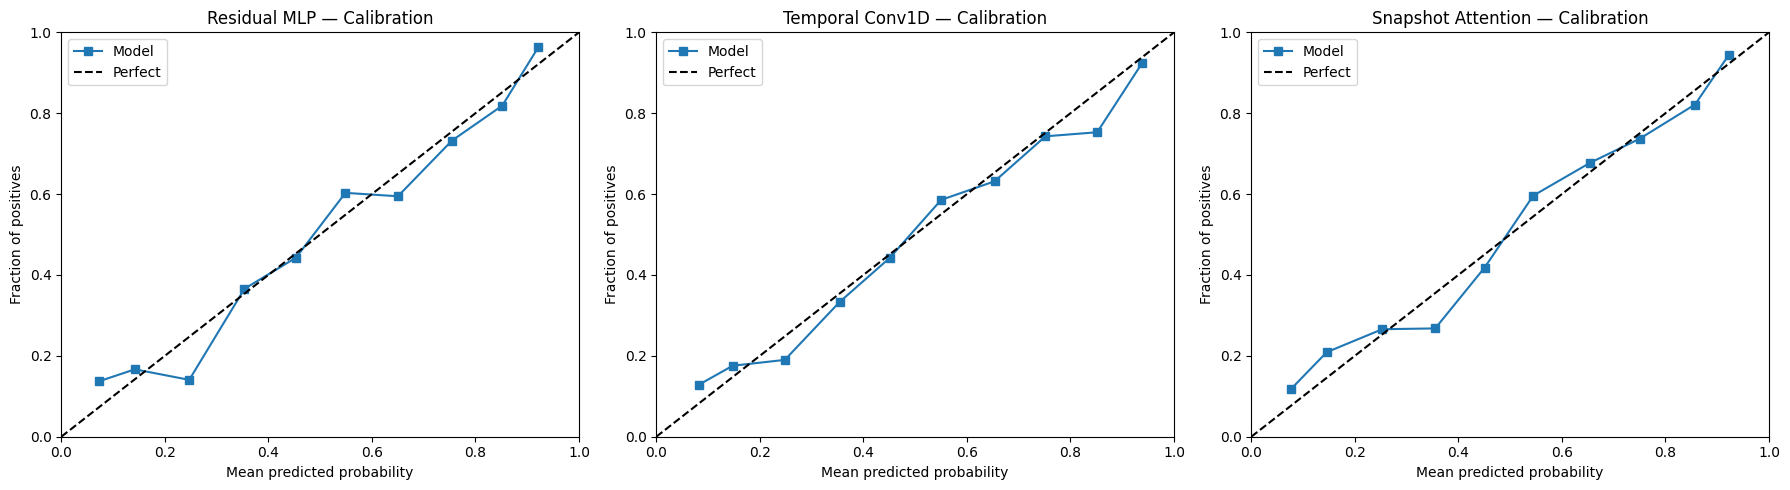

In [13]:
# Calibration curves
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, probs, y_true) in zip(
    axes,
    [
        ("Residual MLP", mlp_metrics["probs"], y_test),
        ("Temporal Conv1D", tcn_metrics["probs"], y_seq_test),
        ("Snapshot Attention", attn_metrics["probs"], y_seq_test),
    ],
    strict=True,
):
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, "s-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"{name} — Calibration")
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Winner Selection

Select the architecture with the best Brier score (our primary metric for confidence-gated strategies). If Brier scores are within 0.005, prefer the simpler/faster model.

The winner determines:
- Which model class to use in `02_export.ipynb`
- Whether `DnnPredictor` should use `temporal=True` or `temporal=False`

In [14]:
# Automated selection by Brier score (lower is better)
candidates = [
    ("Residual MLP", mlp_metrics, "single-snapshot", count_params(mlp), mlp),
    ("Temporal Conv1D", tcn_metrics, "temporal", count_params(tcn), tcn),
    ("Snapshot Attention", attn_metrics, "temporal", count_params(attn), attn),
]

# Sort by Brier (ascending = best first)
candidates.sort(key=lambda x: x[1]["brier"])

best_name, best_metrics, best_type, best_params, best_model = candidates[0]
second_name, second_metrics = candidates[1][0], candidates[1][1]

# If top two are within 0.005 Brier, prefer the simpler/faster one
brier_diff = abs(best_metrics["brier"] - second_metrics["brier"])
if brier_diff < 0.005:
    print(f"Top two Brier scores within {brier_diff:.4f} — checking latency tiebreaker")
    if second_metrics["latency_ms"] < best_metrics["latency_ms"]:
        best_name, best_metrics, best_type, best_params, best_model = candidates[1]
        print(f"Switching to {best_name} (faster)")

print(f"\n{'=' * 60}")
print(f"  WINNER: {best_name}")
print(f"{'=' * 60}")
print(f"  Type:       {best_type}")
print(f"  temporal=   {best_type == 'temporal'}")
print(f"  Brier:      {best_metrics['brier']:.4f}")
print(f"  Accuracy:   {best_metrics['accuracy'] * 100:.1f}%")
print(f"  Latency:    {best_metrics['latency_ms']:.2f} ms")
print(f"  Parameters: {best_params:,}")

# Verify latency constraint
assert best_metrics["latency_ms"] < 10.0, f"Latency {best_metrics['latency_ms']:.2f}ms exceeds 10ms limit!"
print("\n  Latency check PASSED (< 10ms)")

Top two Brier scores within 0.0014 — checking latency tiebreaker

  WINNER: Residual MLP
  Type:       single-snapshot
  temporal=   False
  Brier:      0.1843
  Accuracy:   72.6%
  Latency:    0.08 ms
  Parameters: 136,065

  Latency check PASSED (< 10ms)
